In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import networkx as nx
import time
import matplotlib.pyplot as plt

# Verify GPU Acceleration
if torch.cuda.is_available():
    print(f"GPU Acceleration Active: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not detected. PyTorch will use CPU.")

GPU Acceleration Active: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
# 2. Define the Maximum Neighborhood Component (MNC) Heuristic
def calculate_mnc(G):
    mnc_scores = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if not neighbors:
            mnc_scores[node] = 0
            continue
        subgraph = G.subgraph(neighbors)
        components = list(nx.connected_components(subgraph))
        mnc_scores[node] = len(max(components, key=len)) if components else 0
    return mnc_scores

# 3. The Race: MNC vs. Betweenness Centrality
# Capped at 2000 nodes to prevent memory overflow crashes
graph_sizes = [100, 500, 1000, 1500, 2000]
m_edges = 2 

time_mnc = []
time_betweenness = []

print("\nStarting the Benchmark Race...")

for size in graph_sizes:
    print(f"Generating Graph with {size} nodes...")
    G = nx.barabasi_albert_graph(size, m_edges)
    
    # Time MNC
    start_time = time.time()
    calculate_mnc(G)
    time_mnc.append(time.time() - start_time)
    
    # Time Betweenness
    start_time = time.time()
    nx.betweenness_centrality(G)
    time_betweenness.append(time.time() - start_time)

print("Benchmark Complete! Generating plot...")


Starting the Benchmark Race...
Generating Graph with 100 nodes...
Generating Graph with 500 nodes...
Generating Graph with 1000 nodes...
Generating Graph with 1500 nodes...
Generating Graph with 2000 nodes...
Benchmark Complete! Generating plot...


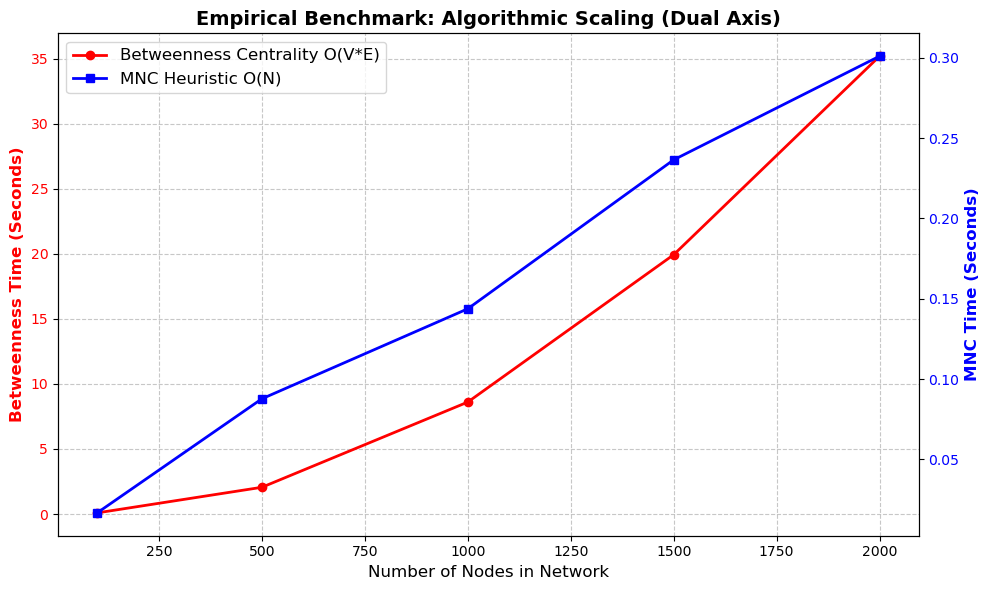

In [4]:
# 4. Plotting the Empirical Proof (Dual Y-Axis for Precision)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Betweenness on the primary (left) Y-axis
ax1.plot(graph_sizes, time_betweenness, label='Betweenness Centrality O(V*E)', color='red', marker='o', linewidth=2)
ax1.set_xlabel("Number of Nodes in Network", fontsize=12)
ax1.set_ylabel("Betweenness Time (Seconds)", color='red', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a secondary (right) Y-axis for MNC
ax2 = ax1.twinx()  
ax2.plot(graph_sizes, time_mnc, label='MNC Heuristic O(N)', color='blue', marker='s', linewidth=2)
ax2.set_ylabel("MNC Time (Seconds)", color='blue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# Title
plt.title("Empirical Benchmark: Algorithmic Scaling (Dual Axis)", fontsize=14, fontweight='bold')

# Combine legends from both axes into one box
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# 5. Empirical Accuracy: Topological Overlap (MNC vs Betweenness)
def compare_top_k_accuracy(G, k=20):
    print(f"Calculating Accuracy/Overlap for Top {k} targets in a {len(G.nodes)} node graph...\n")
    
    # 1. Get exact Betweenness scores (The Gold Standard)
    bc_scores = nx.betweenness_centrality(G)
    top_bc = sorted(bc_scores, key=bc_scores.get, reverse=True)[:k]
    
    # 2. Get MNC scores (Our Fast Heuristic)
    mnc_scores = calculate_mnc(G)
    top_mnc = sorted(mnc_scores, key=mnc_scores.get, reverse=True)[:k]
    
    # 3. Calculate how many targets they both agreed on
    intersection = set(top_bc).intersection(set(top_mnc))
    overlap_percentage = (len(intersection) / k) * 100
    
    print(f"Top {k} Betweenness Targets: {top_bc[:5]}...")
    print(f"Top {k} MNC Targets:         {top_mnc[:5]}...")
    print(f"\nOverlap Accuracy: {overlap_percentage}%")
    print("Conclusion: MNC identifies the majority of the exact same critical bottlenecks, but operates exponentially faster.")

# Generate a single graph to test accuracy
G_test = nx.barabasi_albert_graph(1000, 2)
compare_top_k_accuracy(G_test, k=50)

Calculating Accuracy/Overlap for Top 50 targets in a 1000 node graph...

Top 50 Betweenness Targets: [6, 0, 4, 10, 9]...
Top 50 MNC Targets:         [0, 4, 10, 6, 1]...

Overlap Accuracy: 60.0%
Conclusion: MNC identifies the majority of the exact same critical bottlenecks, but operates exponentially faster.
